In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import zz_feature_map, real_amplitudes, z_feature_map
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import L_BFGS_B
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.optimizers import SPSA 
from qiskit_aer import AerSimulator
from sklearn.model_selection import train_test_split

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [75]:
# ── Configuration ─────────────────────────────────────────────────────────────

# Dataset
n          = 1000    # Number of generated points
TEST_SIZE  = 0.2    # Fraction used for test set
SEED       = 1      # Random seed (data split & optimizer init)
N_DIM      = 6   # Features dimension

# Optimization
MAXITER    = 1000     # minimizer max iterations
optimizer = COBYLA(maxiter=MAXITER) 

# Noise 
USE_NOISE = False 
NOISE_RATE = 0.02
# ──────────────────────────────────────────────────────────────────────────────
REUPLOAD_SHOTS = 2048


In [68]:
if USE_NOISE:
    print("Construction du simulateur BRUITÉ...")
    nm = NoiseModel()
    # Erreur sur les portes simples (1 qubit)
    err1 = depolarizing_error(NOISE_RATE, 1)
    nm.add_all_qubit_quantum_error(err1, ['u', 'h', 'ry', 'rz'])
    # Erreur sur l'intrication (2 qubits) 
    err2 = depolarizing_error(NOISE_RATE * 5, 2)
    nm.add_all_qubit_quantum_error(err2, ['cx'])
    
 
    backend = AerSimulator(noise_model=nm, method="density_matrix")
    sampler = Sampler(backend)
else:
    print("-> Mode IDÉAL")
    sampler = Sampler(AerSimulator())

-> Mode IDÉAL


In [69]:
def generate_nsphere_data(n_samples, n_dim, radius=None):
    # Génération de points entre -1 et 1
    X = np.random.uniform(-1, 1, (n_samples, n_dim))    
    # Le rayon par défaut est choisi pour équilibrer les classes
    if radius is None:
        radius = np.sqrt(n_dim / 3) 
        
    # Calcul de la norme euclidienne au carré
    dist_sq = np.sum(X**2, axis=1)
    y = (dist_sq >= radius**2).astype(int)
    
    return X, y, radius



## Entrainement d'un VQC sur différentes dimensions

In [52]:
all_accuracy = []
for dim in range(N_DIM, N_DIM + 1):
    X, y,_ = generate_nsphere_data(n, dim)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # ZZFeatureMap est excellente pour les frontières non-linéaires (sphères)
    feature_map = zz_feature_map(feature_dimension=dim,reps=2, entanglement='linear')

    # RealAmplitudes avec plus de couches et intrication circulaire 
    ansatz = real_amplitudes(num_qubits=dim, reps=3, entanglement='circular')

    sampler = Sampler(AerSimulator())

    optimizer = COBYLA(maxiter=1000)

    cost_history = []
    def callback(weights, loss):
        cost_history.append(loss)
        print(f"Iteration {len(cost_history)}: Loss = {loss:.4f}")

    # 5. Création et Entraînement du VQC
    vqc = VQC(
        sampler=sampler,
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        callback=callback
    )



    print(f"Entraînement sur {dim} features en cours...")
    vqc.fit(X_train, y_train)

    # 6. Résultats
    accuracy = vqc.score(X_test, y_test)
    print(f"Précision pour {dim} features: {accuracy:.4f}")
    all_accuracy.append(accuracy)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Entraînement sur 6 features en cours...
Précision pour 6 features: 0.5400


### Entrainement statistique

In [77]:
import numpy as np

N_RUNS = 4  # Nombre de répétitions par dimension
all_results = {}

results_mean = []
results_std = []

for dim in range(2,N_DIM + 1):
    run_accuracies = []
    print(f"\n--- Évaluation Dimension {dim} ---")
    
    # 1. Génération des données pour cette dimension
    X, y, _ = generate_nsphere_data(n, dim)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    for i in range(N_RUNS):
        print(f"  Run {i+1}/{N_RUNS}...", end="\r")
        
        # 2. Configuration du circuit (adaptée à la dimension)
        f_map = z_feature_map(feature_dimension=dim, reps=2, entanglement='linear')
        ansatz = real_amplitudes(num_qubits=dim, reps=3, entanglement='circular')
        
        vqc = VQC(
            sampler=sampler,
            feature_map=f_map,
            ansatz=ansatz,
            optimizer=COBYLA(maxiter=MAXITER)
        )

        # 3. Entraînement et Score
        vqc.fit(X_train, y_train)
        acc = vqc.score(X_test, y_test)
        run_accuracies.append(acc)

    # 4. Calcul des statistiques pour cette dimension
    results_mean.append(np.mean(run_accuracies))
    results_std.append(np.std(run_accuracies))
    print(f"  Précision moyenne : {np.mean(run_accuracies):.4f} ± {np.std(run_accuracies):.4f}")

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.



--- Évaluation Dimension 2 ---


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


...

  Précision moyenne : 0.8137 ± 0.0429

--- Évaluation Dimension 6 ---


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


  Précision moyenne : 0.7225 ± 0.0251


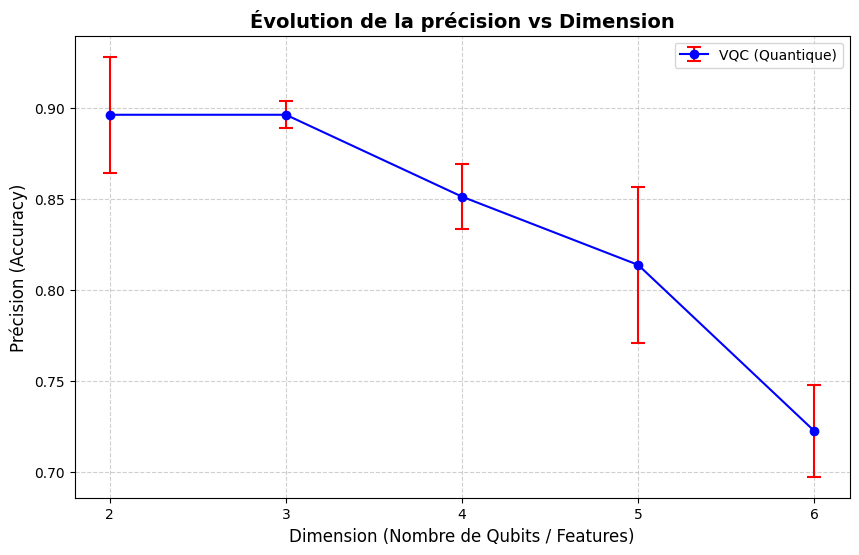

# Réseau de Neurones Classique

In [94]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

all_results_nn = {}
results_mean_nn = []
results_std_nn = []
for dim in range(2, N_DIM + 1):
    run_accuracies_nn = []
    for i in range(N_RUNS):
        X, y,_ = generate_nsphere_data(n, dim)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        mlp = MLPClassifier(hidden_layer_sizes=(8,), max_iter=1000,random_state=42,activation='relu', solver='lbfgs')
        mlp.fit(X_train, y_train)
        y_pred_mlp = mlp.predict(X_test)
        acc_mlp = accuracy_score(y_test, y_pred_mlp)
        run_accuracies_nn.append(acc_mlp)

    results_mean_nn.append(np.mean(run_accuracies_nn))
    results_std_nn.append(np.std(run_accuracies_nn))
    print(f"Précision moyenne Réseau de Neurones Classique en {dim} dimension: {np.mean(run_accuracies_nn) * 100:.2f}% ± {np.std(run_accuracies_nn) * 100:.2f}%")
    



Précision moyenne Réseau de Neurones Classique en 2 dimension: 96.75% ± 0.90%
Précision moyenne Réseau de Neurones Classique en 3 dimension: 95.00% ± 1.84%
Précision moyenne Réseau de Neurones Classique en 4 dimension: 93.00% ± 0.94%
Précision moyenne Réseau de Neurones Classique en 5 dimension: 88.25% ± 0.75%
Précision moyenne Réseau de Neurones Classique en 6 dimension: 88.25% ± 1.15%


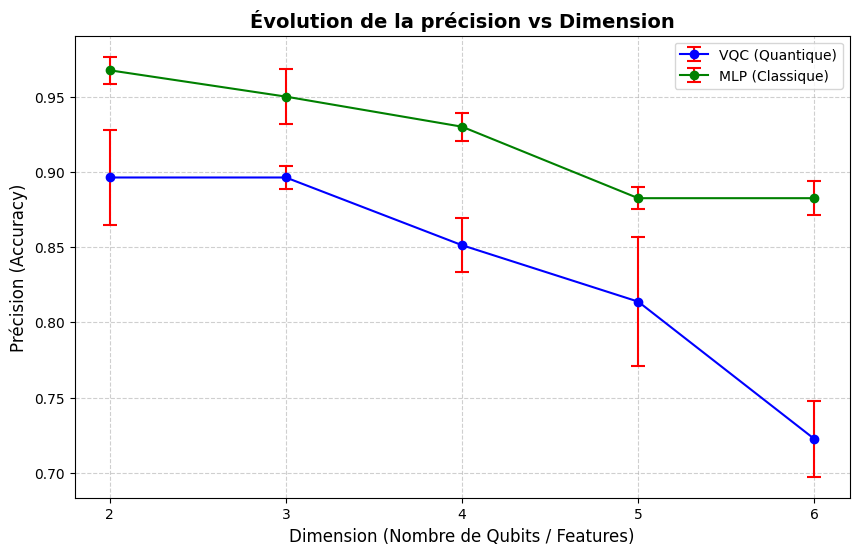

In [95]:
# --- Tes données ---
dimensions = np.arange(2, N_DIM + 1)  # Dimensions de 2 à N_DIM

plt.figure(figsize=(10, 6))

# 1. Courbe pour le VQC avec ses "bâtonnets" d'écart-type
plt.errorbar(dimensions, results_mean, yerr=results_std, 
             fmt='-o',          # '-' pour la ligne, 'o' pour les points
             capsize=5,         # Les petits traits horizontaux au bout des bâtonnets
             color='blue',      # Couleur de la ligne et des points
             ecolor='red',     # Couleur des bâtonnets
             elinewidth=1.5,    # Épaisseur des bâtonnets
             capthick=1.5,      # Épaisseur des extrémités des bâtonnets
             label='VQC (Quantique)')

plt.errorbar(dimensions, results_mean_nn, yerr=results_std_nn, 
             fmt='-o',          # '-' pour la ligne, 'o' pour les points
             capsize=5,         # Les petits traits horizontaux au bout des bâtonnets
             color='green',      # Couleur de la ligne et des points
             ecolor='red',     # Couleur des bâtonnets
             elinewidth=1.5,    # Épaisseur des bâtonnets
             capthick=1.5,      # Épaisseur des extrémités des bâtonnets
             label='MLP (Classique)')

# --- Mise en forme ---
plt.title("Évolution de la précision vs Dimension", fontsize=14, fontweight='bold')
plt.xlabel("Dimension (Nombre de Qubits / Features)", fontsize=12)
plt.ylabel("Précision (Accuracy)", fontsize=12)

plt.xticks(dimensions)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

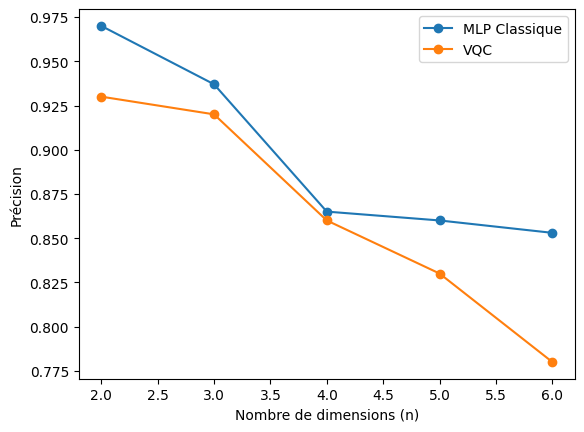

In [54]:
all_acc = [0.97,0.937,0.865,0.86,0.853]
all_accuracy = [0.93,0.92,0.86,0.83,0.78]
plt.figure()
plt.plot(range(2, N_DIM + 1), all_acc, marker='o', label='MLP Classique')
plt.plot(range(2, N_DIM + 1), all_accuracy, marker='o', label='VQC')
plt.xlabel('Nombre de dimensions (n)')
plt.ylabel('Précision')
plt.legend()
plt.show()

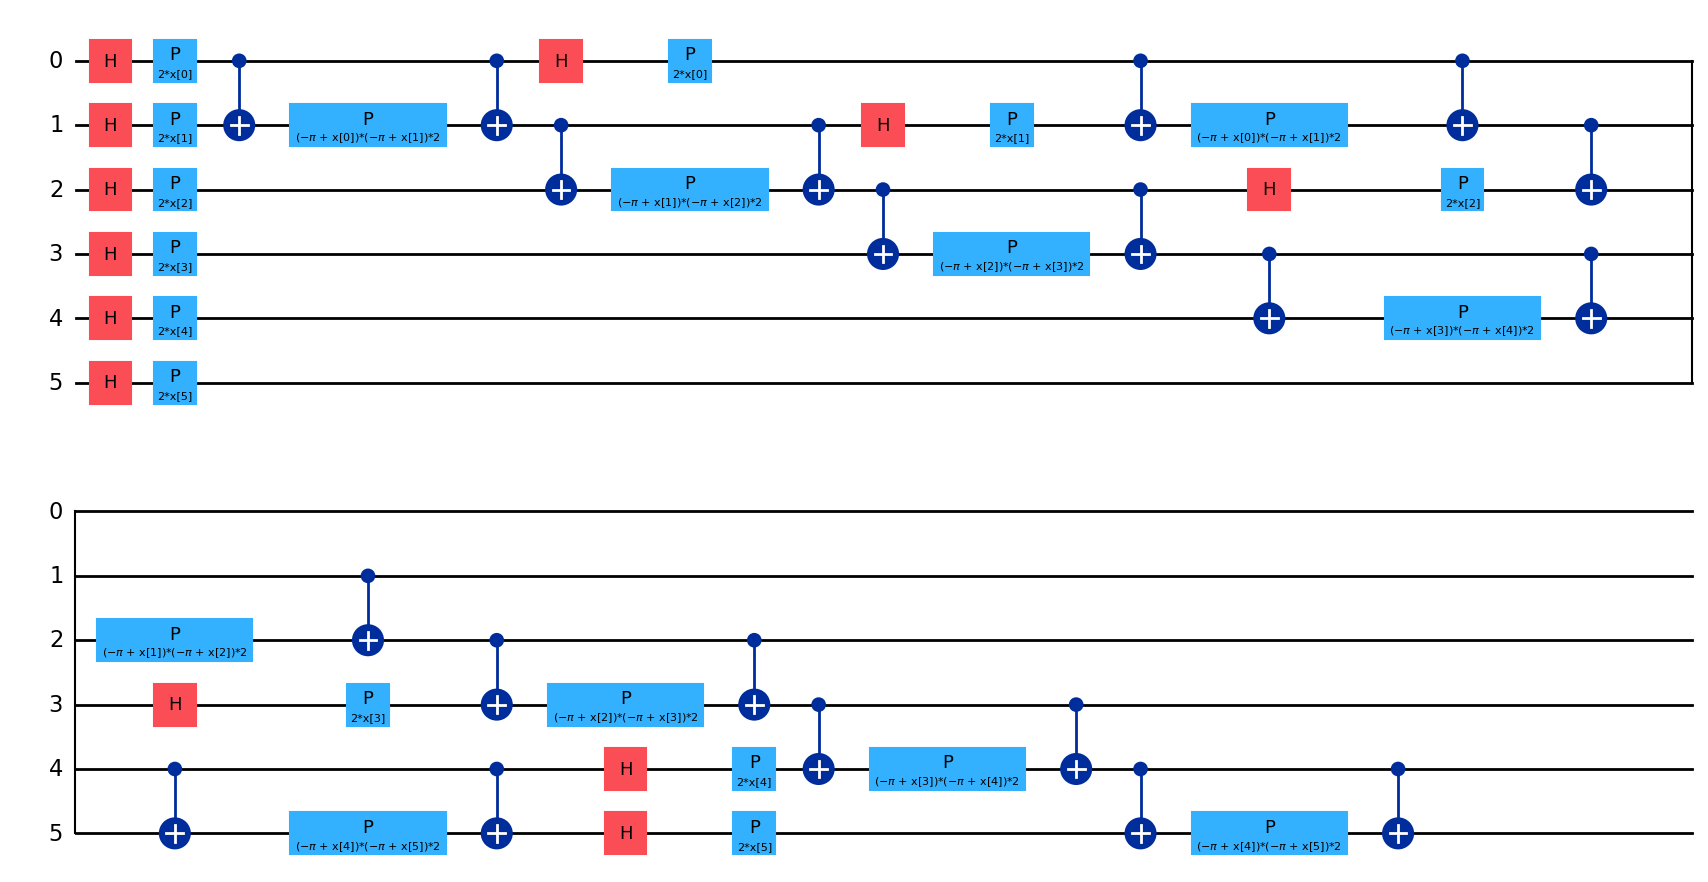

In [53]:
vqc._feature_map.draw('mpl')

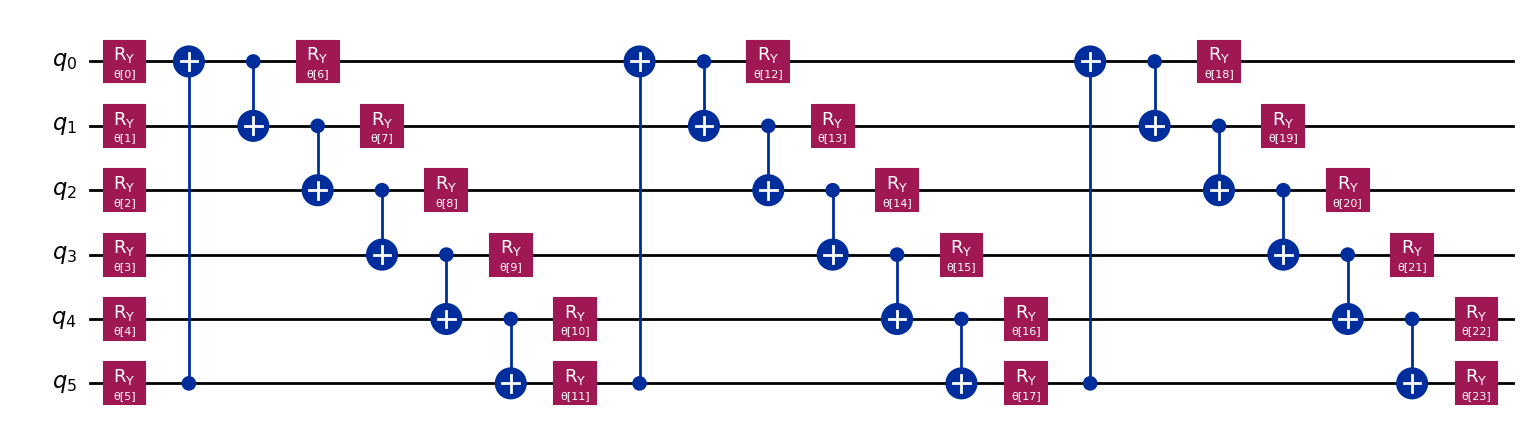

In [50]:
vqc._ansatz.draw('mpl')

In [11]:
vqc.draw()

NameError: name 'vqc' is not defined

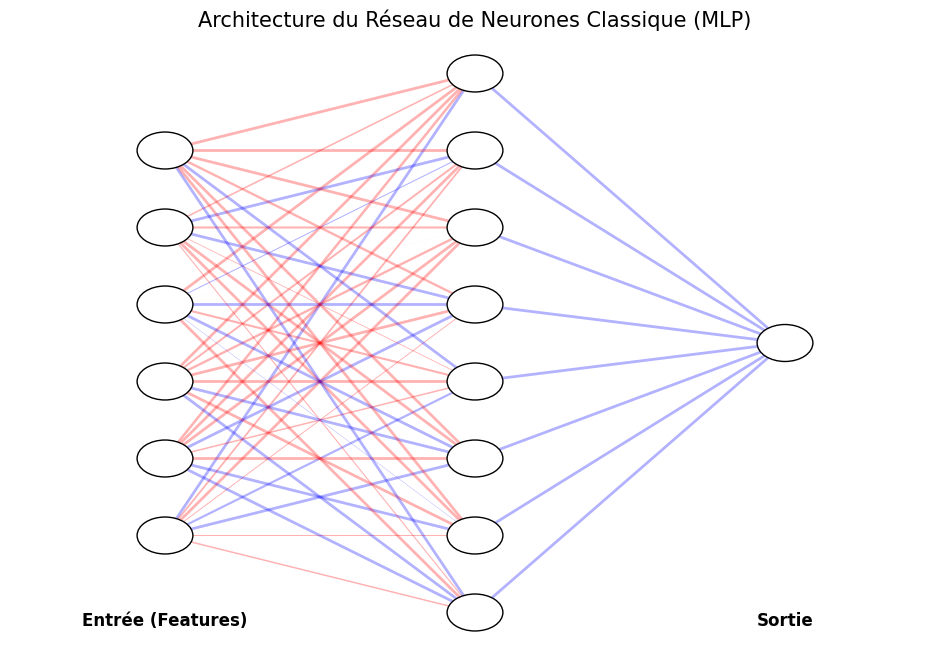

In [98]:
import matplotlib.pyplot as plt
import numpy as np

def draw_mlp(mlp):
    """
    Dessine l'architecture du MLPClassifier de scikit-learn.
    """
    # Récupération de la structure
    # Couche d'entrée + couches cachées + couche de sortie
    layers = [mlp.n_features_in_] + list(mlp.hidden_layer_sizes) + [mlp.n_outputs_]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.axis('off')

    # Paramètres de dessin
    v_spacing = 1.0 / float(max(layers))
    h_spacing = 1.0 / float(len(layers))
    node_radius = 0.03

    # 1. Calcul des positions des neurones
    node_coords = []
    for i, l in enumerate(layers):
        layer_coords = []
        x = i * h_spacing + h_spacing/2
        for j in range(l):
            y = j * v_spacing + (1 - l * v_spacing)/2 + v_spacing/2
            layer_coords.append((x, y))
        node_coords.append(layer_coords)

    # 2. Dessin des connexions (Poids)
    # On ajuste l'épaisseur selon la valeur du poids pour plus de réalisme
    for i in range(len(node_coords) - 1):
        weights = mlp.coefs_[i]
        for n1, start in enumerate(node_coords[i]):
            for n2, end in enumerate(node_coords[i+1]):
                weight_val = weights[n1, n2]
                color = 'blue' if weight_val > 0 else 'red'
                linewidth = min(abs(weight_val) * 2, 2.0) # Épaisseur max 2.0
                ax.annotate("", xy=end, xytext=start,
                            arrowprops=dict(arrowstyle="-", color=color, alpha=0.3, lw=linewidth))

    # 3. Dessin des neurones
    labels = ["Entrée (Features)", "", "Sortie"]
    for i, layer in enumerate(node_coords):
        for x, y in layer:
            circle = plt.Circle((x, y), node_radius, color='white', ec='black', zorder=4)
            ax.add_artist(circle)
        # Ajout des labels sous chaque couche
        ax.text(i * h_spacing + h_spacing/2, 0.05, labels[i], 
                ha='center', va='center', fontsize=12, fontweight='bold')

    plt.title(f"Architecture du Réseau de Neurones Classique (MLP)", fontsize=15)
    plt.show()

draw_mlp(mlp)